In [1]:
import os ; import sys
cipath = "/home/joselado/Documents/programs/tranci" # address where the library is
sys.path.append(cipath+"/src")
import matplotlib.pyplot as plt

# Compute an anisotropy as a function of a crystal field
This example shows how you can modify the crystal field of a system and see how the anisotropy changes

In [2]:
from tranci.atom import get_atom

def get_hamiltonians(D=0.1,E=0.0,soc=0.04):
    """Return single particle and many-body Hamiltonians"""

    # generate a class for an atom with a single electron, to create your custom crystal field  
    Atom_single = get_atom(ne=1) # dummy atom to create the crystal field

    # now write your crystal field using the single particle angular momenta operators
    lx,ly,lz = Atom_single.Operator["lx"],Atom_single.Operator["ly"],Atom_single.Operator["lz"]

    CF = D*lz@lz + E*(lx@lx - ly@ly) # axial and shear
    # now generate a new class for an atom with several electrons
    ne = 6 # number of electrons
    # generate an atom class for the system you want to compute
    Atom = get_atom(ne=ne) 

    # this allows you to define any crystal field by using the angular momenta in the single particle basis
    CF_MB = Atom.one2many(CF) # crystal field in the many body basis

    # you can also apply this idea to any single particle term
    LS = Atom_single.Operator["ls"] # single particle L.S
    LS_MB = Atom.one2many(LS) # SOC in the many-body basis
    # now create your Hamiltonian
    U = 4.0 # Coulomb interaction, spin-orbit coupling, magnetic field and crystal field
    H = U*Atom.Operator["Coulomb"] + CF_MB + soc*LS_MB # many body Hamiltonian
    H_single = CF + soc*LS # single particle Hamiltonian
    return H,H_single

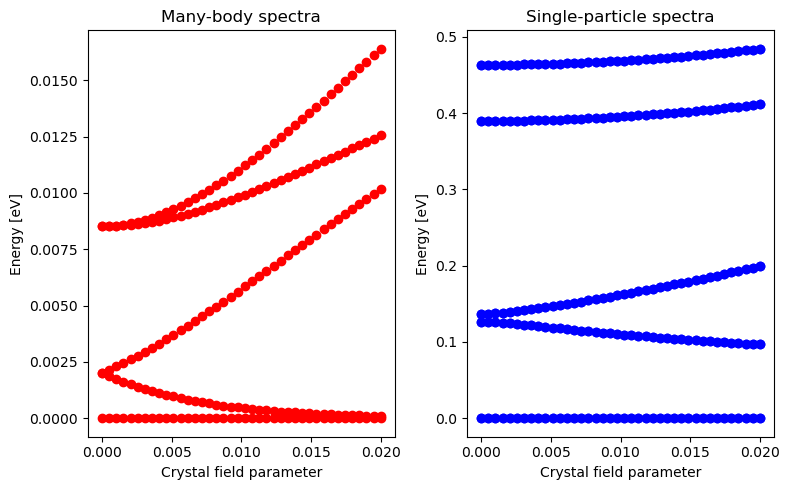

In [3]:
import scipy.linalg as lg
import numpy as np

fig = plt.figure(figsize=[8,5])

Ps = np.linspace(0.,0.02,40)

for P in Ps: # loop over parameters
    H,H_single = get_hamiltonians(D=0.1,E=P,soc=0.04)
    plt.subplot(1,2,1)
    plt.title("Many-body spectra")
    es = lg.eigvalsh(H.todense()) # compute eigenvalues
    es = es - es[0] ; es = es[es<0.05] # retain only the relatively small ones
    plt.scatter(es*0. + P,es,c="red") # plot eigenvalues
    plt.xlabel("Crystal field parameter") ; plt.ylabel("Energy [eV]") ; plt.tight_layout()

    # with the current parameters, this Hamiltonian describes a spin Hamiltonian like S111**2 for S=2

    # plot the single particle spectra as a reference
    plt.subplot(1,2,2)
    plt.title("Single-particle spectra")
    es = lg.eigvalsh(H_single.todense()) # compute eigenvalues
    es = es - es[0]
    plt.scatter(es*0. + P,es,c="blue") # plot eigenvalues 
    plt.xlabel("Crystal field parameter") ; plt.ylabel("Energy [eV]") ; plt.tight_layout()